# Практическое занятие 8. Расчет режима энергосистемы в pandapower

Версия: преподавательская.

Цель занятия - выполнить расчет установившегося режима
электроэнергетической системы и интерпретировать напряжения шин,
загрузку линий и изменение режима при росте нагрузки.

## Инициализация среды выполнения

Ячейка ниже обеспечивает запуск блокнота в Google Colab и в
локальном Jupyter Notebook. Если проект уже открыт локально,
повторное клонирование не выполняется.

In [1]:
# COLAB_BOOTSTRAP_APPailab
from pathlib import Path
import os
import sys

REQUIRED_PROCESSED_FILES = ['practice_08_power_flow_features.csv', 'practice_08_power_flow_diagnostics.csv', 'practice_08_power_flow_scenarios.csv', 'practice_07_09_dataset_catalog.csv', 'practice_07_09_dataset_assignments.csv']
PROJECT_REPOSITORY_URL = "https://github.com/Alexflex/appailab.git"

def find_project_root(start: Path) -> Path | None:
    for candidate in [start, *start.parents]:
        if (candidate / "requirements-colab.txt").exists() and (candidate / "data" / "processed").exists():
            return candidate
    return None

project_root = find_project_root(Path.cwd())

if project_root is None:
    try:
        import google.colab  # type: ignore
        IN_COLAB = True
    except Exception:
        IN_COLAB = False

    if IN_COLAB:
        workdir = Path("/content/appailab")
        if not workdir.exists():
            !git clone -q {PROJECT_REPOSITORY_URL} {workdir}
        project_root = workdir
        os.chdir(project_root)
        !pip install -q -r requirements-colab.txt
    else:
        raise FileNotFoundError(
            "Не найден корень проекта. Откройте блокнот из репозитория appailab "
            "или выполните git clone перед запуском."
        )

sys.path.insert(0, str(project_root / "src"))
missing_files = [
    name for name in REQUIRED_PROCESSED_FILES
    if not (project_root / "data" / "processed" / name).exists()
]
if missing_files:
    raise FileNotFoundError(
        "Не найдены подготовленные CSV: " + ", ".join(missing_files)
        + ". Выполните python scripts/generate_datasets.py."
    )

print(f"Корень проекта: {project_root}")
print("Проверенные CSV:", ", ".join(REQUIRED_PROCESSED_FILES))

Корень проекта: /mnt/f/projects/appai_lab
Проверенные CSV: practice_08_power_flow_features.csv, practice_08_power_flow_diagnostics.csv, practice_08_power_flow_scenarios.csv, practice_07_09_dataset_catalog.csv, practice_07_09_dataset_assignments.csv


In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

DATA_DIR = project_root / "data" / "processed"
CATALOG_07_09_FILE = DATA_DIR / "practice_07_09_dataset_catalog.csv"
ASSIGNMENTS_07_09_FILE = DATA_DIR / "practice_07_09_dataset_assignments.csv"
RANDOM_STATE = 20260507

## Теоретический блок

Расчет режима энергосистемы (power flow calculation, load flow
calculation) определяет модули и углы напряжений в шинах, потоки
активной и реактивной мощности, а также загрузку линий. AC power
flow - расчет переменного тока, в котором учитываются активная
мощность `P`, реактивная мощность `Q`, модуль напряжения `U` и
фазовый угол.

Баланс мощности в узле:

$$
P_{gen} - P_{load} = P_{injected},\quad
Q_{gen} - Q_{load} = Q_{injected}.
$$

## Последовательность работы

1. Загрузить сценарии нагрузки и генерации.
2. Создать учебную 6-узловую сеть 110 kV в `pandapower`.
3. Выполнить AC power flow для базового сценария.
4. Сравнить базовый режим и режим с увеличенной нагрузкой.
5. Найти слабый узел и наиболее нагруженную линию.
6. Объяснить, почему расчет режима не является заменой машинному
   обучению.

In [3]:
features_df = pd.read_csv(DATA_DIR / "practice_08_power_flow_features.csv")
diagnostics_df = pd.read_csv(DATA_DIR / "practice_08_power_flow_diagnostics.csv")
scenarios_df = pd.read_csv(DATA_DIR / "practice_08_power_flow_scenarios.csv")

print("features:", features_df.shape)
print("diagnostics:", diagnostics_df.shape)
print("scenarios:", scenarios_df.shape)
display(scenarios_df.head())
display(features_df.head())

features: (120, 11)
diagnostics: (120, 29)
scenarios: (120, 13)


,scenario_id,scenario_label,load_scale,generator_p_mw,generator_vm_pu,load_bus_2_mw,load_bus_2_mvar,load_bus_3_mw,load_bus_3_mvar,load_bus_4_mw,load_bus_4_mvar,load_bus_5_mw,load_bus_5_mvar
0,1,base,1.0000,35.0000,1.01000,29.2651,10.4014,24.3143,8.0800,26.6198,8.8305,16.7234,5.2234
1,2,random_operating_point,0.8809,29.4418,1.02678,28.8040,10.9120,24.0267,8.8749,20.3105,7.8871,14.7974,4.9755
2,3,random_operating_point,1.2000,29.3818,1.01905,40.3696,14.8323,30.3518,10.2967,35.5466,11.7926,20.6785,7.4098
3,4,random_operating_point,0.9092,44.0281,1.02416,30.6055,10.1539,20.4259,6.9603,25.1330,9.0073,15.2678,5.6387
4,5,high_load,1.2504,33.9256,1.00148,44.7200,16.8040,27.6618,8.7903,34.7358,11.9680,23.6438,7.3509


,scenario_id,scenario_label,total_load_mw,total_reactive_load_mvar,generator_p_mw,generator_vm_pu,min_vm_pu,max_line_loading_percent,total_line_loss_mw,weak_bus,critical_line
0,1,base,96.9226,32.5353,35.0000,1.01000,0.99889,72.065,0.88375,5,1
1,2,random_operating_point,87.9386,32.6495,29.4418,1.02678,1.01413,70.406,0.82892,5,1
2,3,random_operating_point,126.9465,44.3314,29.3818,1.01905,1.00130,114.639,2.09033,5,1
3,4,random_operating_point,91.4322,31.7602,44.0281,1.02416,1.01102,56.245,0.65561,5,1
4,5,high_load,130.7614,44.9132,33.9256,1.00148,0.98498,114.117,2.10752,5,1


## Паспорт сети

Учебная сеть содержит 6 шин напряжением 110 kV, внешнюю сеть,
один генератор и четыре нагрузки. Одна строка сценариев задает
входы расчета. Столбцы с напряжениями и загрузкой линий являются
результатами расчета, а не исходными признаками.

In [4]:
display(features_df.groupby("scenario_label").agg(
    n=("scenario_id", "count"),
    mean_load=("total_load_mw", "mean"),
    mean_min_vm=("min_vm_pu", "mean"),
    mean_max_loading=("max_line_loading_percent", "mean"),
).round(4))

,n,mean_load,mean_min_vm,mean_max_loading
scenario_label,,,,
base,1,96.9226,0.9989,72.0650
high_load,24,130.8703,0.9947,115.4596
low_generation,14,119.1456,0.9980,111.9842
random_operating_point,74,106.2582,1.0020,84.7898
redistributed_load,7,118.3735,0.9968,94.1930


## Расчет базового режима в pandapower

В этой ячейке используется та же функция построения сети, что и при
генерации CSV. Это позволяет студенту увидеть объект `pandapower`
и результат `runpp`, не переписывая большой код создания сети.

In [5]:
from appai_lab.data_generators import _create_power_flow_network
import pandapower as pp

base_scenario = scenarios_df.iloc[0].to_dict()
net = _create_power_flow_network(base_scenario)
pp.runpp(net, algorithm="nr", init="flat", numba=False)
display(net.bus[["name", "vn_kv"]])
display(net.res_bus[["vm_pu", "va_degree"]].round(4))
display(net.res_line[["p_from_mw", "q_from_mvar", "loading_percent"]].round(3))

,name,vn_kv
0,Grid,110.0
1,Bus 1,110.0
2,Bus 2,110.0
3,Bus 3,110.0
4,Bus 4,110.0
5,Bus 5,110.0


,vm_pu,va_degree
0,1.0200,0.0000
1,1.0108,-1.6290
2,1.0007,-2.8224
3,1.0100,-2.2242
4,1.0017,-2.8771
5,0.9989,-3.1022


,p_from_mw,q_from_mvar,loading_percent
0,62.806,4.561,72.065
1,38.301,7.907,45.348
2,24.052,-4.387,28.212
3,1.237,-2.702,3.464
4,34.676,13.861,43.381
5,9.165,3.247,11.643
6,7.579,0.263,8.962


## Визуальный анализ сценариев

Диаграммы ниже показывают, как рост суммарной нагрузки связан со
снижением минимального напряжения и ростом загрузки наиболее
нагруженной линии.

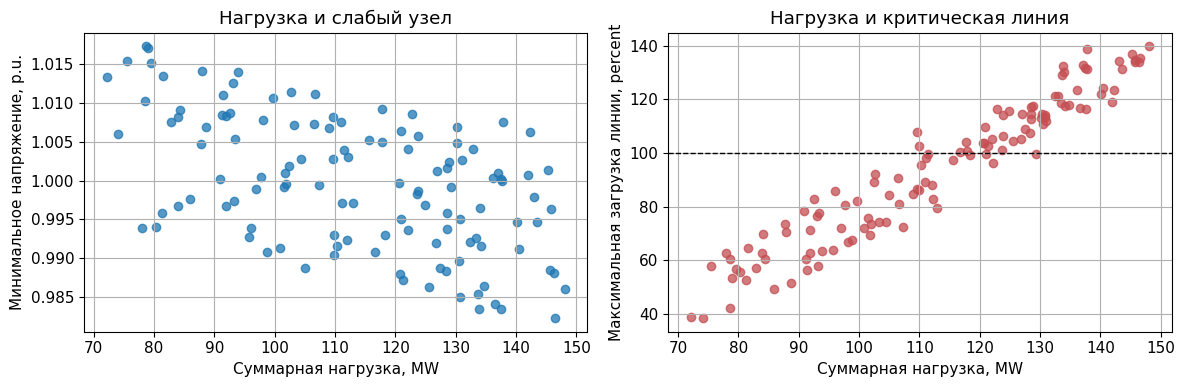

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(features_df["total_load_mw"], features_df["min_vm_pu"], alpha=0.75)
axes[0].set_xlabel("Суммарная нагрузка, MW")
axes[0].set_ylabel("Минимальное напряжение, p.u.")
axes[0].set_title("Нагрузка и слабый узел")

axes[1].scatter(features_df["total_load_mw"], features_df["max_line_loading_percent"], alpha=0.75, color="#c44e52")
axes[1].axhline(100.0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Суммарная нагрузка, MW")
axes[1].set_ylabel("Максимальная загрузка линии, percent")
axes[1].set_title("Нагрузка и критическая линия")
plt.tight_layout()
plt.show()

In [7]:
load_multiplier = 1.2

In [8]:
voltage_limit_pu = 0.97

## Сравнение базового и измененного режима

Изменение нагрузки применяется к одному расчетному сценарию. Это
не обучение модели, а инженерный численный эксперимент.

In [9]:
changed = dict(base_scenario)
for bus in [2, 3, 4, 5]:
    changed[f"load_bus_{bus}_mw"] *= load_multiplier
    changed[f"load_bus_{bus}_mvar"] *= load_multiplier

changed_net = _create_power_flow_network(changed)
pp.runpp(changed_net, algorithm="nr", init="flat", numba=False)

comparison = pd.DataFrame({
    "bus": net.bus["name"].to_numpy(),
    "base_vm_pu": net.res_bus["vm_pu"].to_numpy(),
    "changed_vm_pu": changed_net.res_bus["vm_pu"].to_numpy(),
})
comparison["delta_vm_pu"] = comparison["changed_vm_pu"] - comparison["base_vm_pu"]
comparison["below_limit_after_change"] = comparison["changed_vm_pu"] < voltage_limit_pu
display(comparison.round(5))

line_comparison = pd.DataFrame({
    "line": net.line["name"].to_numpy(),
    "base_loading_percent": net.res_line["loading_percent"].to_numpy(),
    "changed_loading_percent": changed_net.res_line["loading_percent"].to_numpy(),
})
line_comparison["delta_loading_percent"] = (
    line_comparison["changed_loading_percent"] - line_comparison["base_loading_percent"]
)
display(line_comparison.round(3))

,bus,base_vm_pu,changed_vm_pu,delta_vm_pu,below_limit_after_change
0,Grid,1.02000,1.02000,0.00000,False
1,Bus 1,1.01077,1.00984,-0.00093,False
2,Bus 2,1.00065,0.99792,-0.00273,False
3,Bus 3,1.01000,1.01000,0.00000,False
4,Bus 4,1.00170,0.99953,-0.00217,False
5,Bus 5,0.99889,0.99595,-0.00294,False


,line,base_loading_percent,changed_loading_percent,delta_loading_percent
0,Line 1,72.065,94.693,22.627
1,Line 2,45.348,56.231,10.882
2,Line 3,28.212,40.949,12.738
3,Line 4,3.464,5.678,2.214
4,Line 5,43.381,51.168,7.787
5,Line 6,11.643,13.689,2.046
6,Line 7,8.962,11.317,2.355


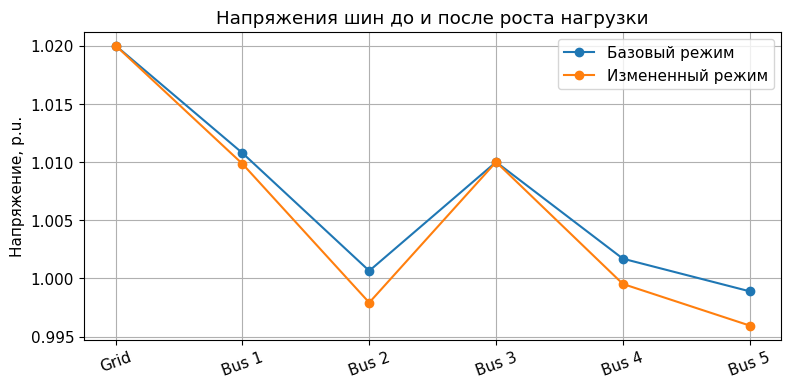

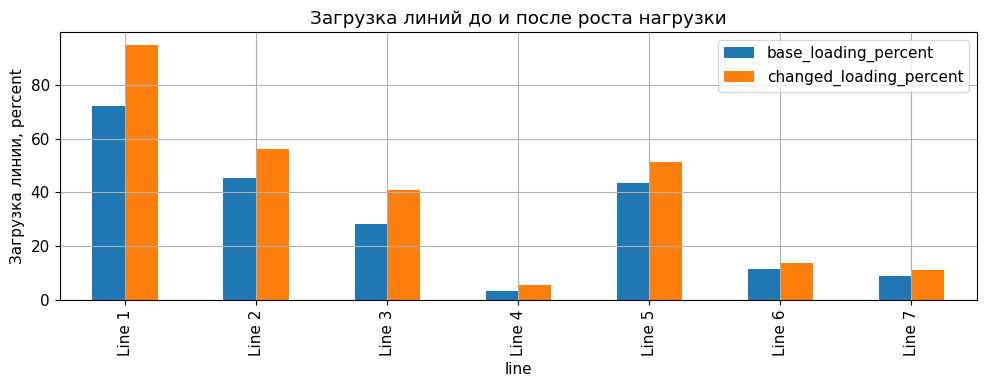

In [10]:
plt.figure(figsize=(9, 4))
x = np.arange(len(comparison))
plt.plot(x, comparison["base_vm_pu"], marker="o", label="Базовый режим")
plt.plot(x, comparison["changed_vm_pu"], marker="o", label="Измененный режим")
plt.xticks(x, comparison["bus"], rotation=20)
plt.ylabel("Напряжение, p.u.")
plt.title("Напряжения шин до и после роста нагрузки")
plt.legend()
plt.show()

line_comparison.plot(x="line", y=["base_loading_percent", "changed_loading_percent"], kind="bar", figsize=(10, 4))
plt.ylabel("Загрузка линии, percent")
plt.title("Загрузка линий до и после роста нагрузки")
plt.tight_layout()
plt.show()

## АНТИПРИМЕР: расчет режима не является задачей машинного обучения

Нельзя подменять физический расчет простым подбором зависимости без
понимания входов и ограничений сети. Машинное обучение может быть
полезным дополнением, но базовый режим должен проверяться расчетной
моделью и инженерными ограничениями.

In [11]:
power_flow_interpretation = 'При росте нагрузки минимальное напряжение снижается, а наиболее загруженной остается линия 1; это указывает на чувствительность головного участка сети.'
print(power_flow_interpretation)

При росте нагрузки минимальное напряжение снижается, а наиболее загруженной остается линия 1; это указывает на чувствительность головного участка сети.


## Источники и проверка актуальности

Базовые занятия 7-9 используют локальные воспроизводимые CSV. Открытые
источники ниже применяются как методические задания: студент должен
определить объект, признаки, целевую переменную, риски утечки данных
и допустимые визуализации.

In [12]:
catalog_07_09 = pd.read_csv(CATALOG_07_09_FILE)
assignments_07_09 = pd.read_csv(ASSIGNMENTS_07_09_FILE)
display(catalog_07_09[[
    "dataset_id", "name", "lessons", "implementation_status",
    "risk_level", "checked_at"
]])

,dataset_id,name,lessons,implementation_status,risk_level,checked_at
0,mendeley_pd_cables_toa,Partial Discharge Signals in Insulated Power C...,7,methodology_only,средний,2026-05-16
1,zenodo_pd_calibrator,Dataset for New Synthetic Partial Discharge Ca...,7,methodology_only,низкий,2026-05-16
2,pandapower_case9,pandapower IEEE 9-bus example network,"8,9",methodology_only,низкий,2026-05-16
3,ieee_pes_test_feeders,IEEE PES Distribution Test Feeders,"8,9",methodology_only,средний,2026-05-16
4,matpower_cases,MATPOWER case archive,"8,9",methodology_only,средний,2026-05-16


## Реестр найденных наборов данных и развернутые задания

Все источники имеют статус `methodology_only`, то есть на данном
этапе они не являются обязательными для выполнения в аудитории.

In [13]:
display(assignments_07_09[[
    "assignment_id", "lesson", "assignment_title",
    "recommended_visualizations", "control_questions"
]])

,assignment_id,lesson,assignment_title,recommended_visualizations,control_questions
0,mendeley_pd_cables_toa_lesson_7,7,Извлечение признаков из сигналов: Partial Disc...,временной сигнал; спектр; таблица признаков; м...,Почему шаг дискретизации входит в расчет энерг...
1,zenodo_pd_calibrator_lesson_7,7,Извлечение признаков из сигналов: Dataset for ...,временной сигнал; спектр; таблица признаков; м...,Почему шаг дискретизации входит в расчет энерг...
2,pandapower_case9_lesson_8,8,Расчет режима по открытой тестовой сети: panda...,таблица напряжений; диаграмма загрузки линий; ...,Что является входом расчета? Почему расчет реж...
3,pandapower_case9_lesson_9,9,Сравнение AC/DC и суррогатной модели: pandapow...,AC против DC; распределение ошибок; график про...,Когда DC-приближение допустимо? Почему AC-резу...
4,ieee_pes_test_feeders_lesson_8,8,Расчет режима по открытой тестовой сети: IEEE ...,таблица напряжений; диаграмма загрузки линий; ...,Что является входом расчета? Почему расчет реж...
5,ieee_pes_test_feeders_lesson_9,9,Сравнение AC/DC и суррогатной модели: IEEE PES...,AC против DC; распределение ошибок; график про...,Когда DC-приближение допустимо? Почему AC-резу...
6,matpower_cases_lesson_8,8,Расчет режима по открытой тестовой сети: MATPO...,таблица напряжений; диаграмма загрузки линий; ...,Что является входом расчета? Почему расчет реж...
7,matpower_cases_lesson_9,9,Сравнение AC/DC и суррогатной модели: MATPOWER...,AC против DC; распределение ошибок; график про...,Когда DC-приближение допустимо? Почему AC-резу...


## Контрольный чек-лист отчета

1. Описаны элементы сети и входные параметры сценария.
2. Приведены таблицы напряжений шин и загрузки линий.
3. Построены графики сравнения базового и измененного режима.
4. Указаны слабый узел и критическая линия.
5. Объяснено отличие расчета режима от модели машинного обучения.